# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** Muhammad Talha

**Roll Number:** 023-24-0269

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook works through Parts 1–12 of the Lab 2 manual on the Telco Customer Churn dataset. Every chart and cleaning decision is followed by a short written interpretation, as required by the rubric.

---

## Setup

Import the libraries needed and load the dataset.

In [45]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The telecom company wants to know, ahead of time, which of its current customers are likely to cancel their service (churn), so it can offer them a retention deal or better support before they actually leave. This turns a business question ("who is about to leave, and why?") into a data problem: predict the binary label `Churn` (Yes/No) for each customer using their account, billing, and service information.

**Answer 2:**
Likely useful predictors:
1. `tenure` — how long someone has been a customer usually tracks loyalty; very new customers seem more likely to leave.
2. `Contract` — a month-to-month customer can leave any time, a two-year contract customer can't, so this should matter a lot.
3. `MonthlyCharges` — customers paying more may feel they're not getting value for money and churn more.
4. `InternetService` (esp. Fiber optic vs DSL vs None) — service type/quality can drive satisfaction.
5. `PaymentMethod` — automatic payments vs manual ones (electronic/mailed check) may correlate with how engaged/organized a customer is.

Likely useless predictors:
1. `customerID` — it's a unique identifier with no relationship to behavior; it can't generalize to a new customer.
2. `gender` — no obvious business reason a person's gender would affect whether they cancel a phone/internet plan.

**Answer 3:**
1. Do customers on flexible (month-to-month) contracts really churn far more than those locked into annual contracts, and by how much?
2. Is there a "danger zone" in the first few months of tenure where churn risk is highest, after which it drops off?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents.

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [46]:
# Task 4 — dataset shape, column names, data types
print("Dataset Shape:", df.shape)
print("Number of Customers (rows):", df.shape[0])
print("Number of Columns:", df.shape[1])
print()
print("Data types:")
print(df.dtypes)
print()
print("Numerical features:", df.select_dtypes(include=[np.number]).columns.tolist())
print("Categorical features (object/string):", df.select_dtypes(include='object').columns.tolist())

Dataset Shape: (7043, 21)
Number of Customers (rows): 7043
Number of Columns: 21

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Numerical features: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical features (object/string): ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMov

In [47]:
# Task 5 — identify identifier columns / wrong data types
print("customerID sample values:")
print(df['customerID'].head())
print("customerID unique count vs row count:", df['customerID'].nunique(), "vs", len(df))
print()
print("TotalCharges dtype:", df['TotalCharges'].dtype)
print("TotalCharges sample values:")
print(df['TotalCharges'].head())

# customerID: every value is unique -> pure identifier, not predictive on its own.
# TotalCharges: should be numeric (it's a dollar amount) but pandas read it as
# an object/string column -> a sign it contains non-numeric entries somewhere.
# SeniorCitizen is stored as 0/1 (int64) even though it's really a Yes/No
# categorical flag -- worth noting, though it doesn't need fixing for EDA.

customerID sample values:
0    7590-VHVEG
1    5575-GNVDE
2    3668-QPYBK
3    7795-CFOCW
4    9237-HQITU
Name: customerID, dtype: object
customerID unique count vs row count: 7043 vs 7043

TotalCharges dtype: object
TotalCharges sample values:
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: object


In [48]:
# Task 6 — unique values in 3 categorical columns
print("Unique values in 'InternetService':", df['InternetService'].unique())
print("Unique values in 'Contract':", df['Contract'].unique())
print("Unique values in 'PaymentMethod':", df['PaymentMethod'].unique())

Unique values in 'InternetService': ['DSL' 'Fiber optic' 'No']
Unique values in 'Contract': ['Month-to-month' 'One year' 'Two year']
Unique values in 'PaymentMethod': ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


**Observations (Part 2):**
The dataset has 7,043 customers and 21 columns. Numerical columns are `SeniorCitizen`, `tenure`, and `MonthlyCharges` (`TotalCharges` *should* be numerical too but pandas loaded it as an object/string column, which is a red flag investigated in Part 3). The remaining columns are categorical — mostly Yes/No/"No \<service\> service" style flags, plus `gender`, `Contract`, `InternetService`, and `PaymentMethod`, which have 3–4 categories each. `customerID` is a pure identifier (7,043 unique values for 7,043 rows) and won't help a model generalize. The three categorical columns checked don't show any inconsistent spelling or stray categories (e.g. no `"dsl"` vs `"DSL"` duplicates) — the category *values* look clean, it's really the `TotalCharges` *type* that needs attention.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems.

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems require action, and which don't?
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [49]:
# Task 7 — missing values: count and percentage per column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'missing_count': missing_count, 'missing_pct': missing_pct.round(2)})
print(missing_report[missing_report['missing_count'] > 0])
print()
print("Total columns with NaN reported by pandas:", (missing_count > 0).sum())

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Total columns with NaN reported by pandas: 0


In [50]:
# Task 8 — duplicate rows vs duplicate IDs
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicate customerID values:", df['customerID'].duplicated().sum())

Fully duplicated rows: 0
Duplicate customerID values: 0


In [51]:
# Task 9 — investigate a suspicious / invalid value
# pandas reports zero NaN, but TotalCharges is stored as text (Task 5) -- that's
# suspicious on its own. Search it directly for blank/whitespace entries.
blank_mask = df['TotalCharges'].astype(str).str.strip() == ''
print("Rows where TotalCharges is blank/whitespace:", blank_mask.sum())
df[blank_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Rows where TotalCharges is blank/whitespace: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


**Answer 7 (which missing-value problems require action, and which don't):**
`df.isnull().sum()` reports **zero** true NaN values in any column — but that's misleading. `TotalCharges` is a text column, and Task 9 shows 11 rows where its value is just a whitespace string `" "` rather than a number. Pandas doesn't count that as missing because it's technically a non-empty string, but it *is* a missing value in disguise and needs action: those 11 rows must be converted to real NaN (via `pd.to_numeric(..., errors='coerce')`) before they can be handled. Every other column is genuinely complete, so no action is needed elsewhere.

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
They are different checks, and in this dataset both come back at **0**. `df.duplicated().sum()` looks for rows that are identical across *every* column, which would suggest the exact same record was accidentally loaded twice. `df['customerID'].duplicated().sum()` only checks the ID column, which would catch a *different* problem — the same customer appearing twice with possibly different (e.g. updated) values in the other columns. A dataset could have zero full-row duplicates but still have duplicate IDs (or vice versa), so both need to be checked separately even though they happen to agree here.

**Answer 9 (suspicious value found and how):**
By reading `TotalCharges` as text and printing a sample (Task 5), the values *looked* numeric but the column's dtype was `object`, which shouldn't happen for a clean numeric column. Explicitly searching for blank/whitespace strings (Task 9) confirmed 11 rows where `TotalCharges` is just `" "`. All 11 of those rows have `tenure == 0`, i.e. brand-new customers who haven't been billed yet — which explains *why* the value is missing rather than it being a random data-entry error.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe.

**Tasks**
10. For every data-quality issue found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm each issue is resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| `TotalCharges` stored as text (object dtype) with 11 blank `" "` entries | Convert to numeric, turning the blanks into real `NaN` | `pd.to_numeric(df['TotalCharges'], errors='coerce')` | The column represents a dollar amount and must be numeric for any statistics/plots/modeling to work correctly. |
| The 11 rows with missing `TotalCharges` all have `tenure == 0` (brand-new customers, no bill yet) | Fill with `0` rather than dropping the rows or imputing the mean | `fillna(0)` | A customer with zero months of tenure genuinely has zero total charges so far — this isn't a random gap to guess at, it's a logically correct value. Dropping the rows would lose 11 real customers for no reason. |
| `SeniorCitizen` stored as `0`/`1` integers instead of Yes/No like the other Yes/No flag columns | Leave the values as-is, but note the inconsistency | — (documentation only) | It's numerically valid (0/1 works fine for both EDA and future modeling) and remapping it to "Yes"/"No" would just have to be re-encoded to 0/1 again for Lab 3, so changing it now adds no real value. |
| `customerID` is a unique identifier, not a predictive feature | Keep it in the cleaning stage for traceability, but flag it as "drop before modeling" in the ML-readiness table (Part 10) | — (documentation only) | It's still useful to keep customer-level traceability during EDA (e.g. to look up a specific row), but a raw ID must never be used as a model input. |
| No full-row duplicates and no duplicate `customerID`s found | No action needed | `drop_duplicates()` not required | Both checks in Part 3 returned 0, so there's nothing to remove. |

In [52]:
# Task 11 — apply cleaning decisions
df_clean_stage = df.copy()

# 1) TotalCharges: convert to numeric, coercing blanks to NaN, then fill with 0
#    (those rows are all tenure == 0, i.e. genuinely zero charges so far)
df_clean_stage['TotalCharges'] = pd.to_numeric(df_clean_stage['TotalCharges'], errors='coerce')
df_clean_stage['TotalCharges'] = df_clean_stage['TotalCharges'].fillna(0)

df_clean_stage.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [53]:
# Task 11 (continued) — confirm each issue is resolved
print("Remaining NaNs in TotalCharges:", df_clean_stage['TotalCharges'].isnull().sum())
print("TotalCharges dtype now:", df_clean_stage['TotalCharges'].dtype)
print("Duplicated rows:", df_clean_stage.duplicated().sum())
print("Duplicated customerIDs:", df_clean_stage['customerID'].duplicated().sum())
print()
print("Rows that previously had blank TotalCharges (now filled with 0):")
df_clean_stage.loc[df['TotalCharges'].astype(str).str.strip() == '', ['customerID','tenure','TotalCharges']]

Remaining NaNs in TotalCharges: 0
TotalCharges dtype now: float64
Duplicated rows: 0
Duplicated customerIDs: 0

Rows that previously had blank TotalCharges (now filled with 0):


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,0.0
753,3115-CZMZD,0,0.0
936,5709-LVOEQ,0,0.0
1082,4367-NUYAO,0,0.0
1340,1371-DWPAZ,0,0.0
3331,7644-OMVMY,0,0.0
3826,3213-VVOLG,0,0.0
4380,2520-SGTTA,0,0.0
5218,2923-ARZLG,0,0.0
6670,4075-WKNIU,0,0.0


---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships.

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

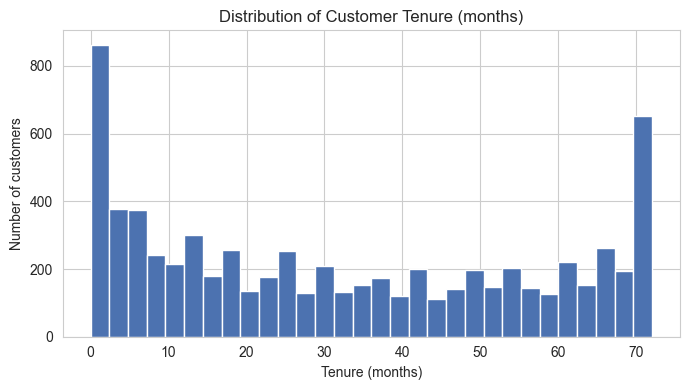

In [56]:
# Task 12 — numerical feature 1: tenure distribution
plt.figure(figsize=(7,4))
plt.hist(df_clean_stage['tenure'], bins=30, color='#4C72B0', edgecolor='white')
plt.title('Distribution of Customer Tenure (months)')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

**Observation:** Tenure is far from a normal bell curve — there's a large spike near 0–1 month and another buildup near 70–72 months, with a fairly flat middle. This is a classic sign of a subscription business: a steady stream of brand-new customers, a smaller pool who "stick" long-term, and a lot of natural attrition in between.

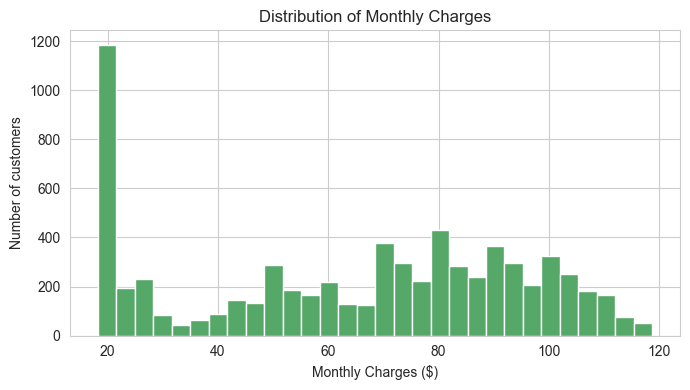

In [55]:
# Task 12 — numerical feature 2: MonthlyCharges distribution
plt.figure(figsize=(7,4))
plt.hist(df_clean_stage['MonthlyCharges'], bins=30, color='#55A868', edgecolor='white')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

**Observation:** `MonthlyCharges` is multi-modal rather than smooth — there's a big cluster around \$20 (customers with only phone service, no internet) and a broader hump from roughly \$70–\$100 (customers bundling internet + extra services). This suggests charges are driven by discrete service bundles rather than one continuous pricing scale.

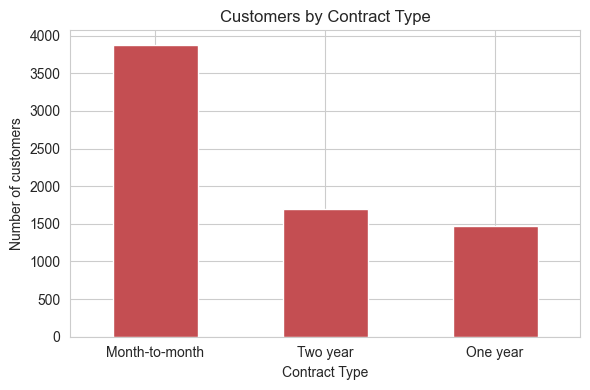

In [54]:
# Task 12 — categorical feature 1: Contract distribution
plt.figure(figsize=(6,4))
df_clean_stage['Contract'].value_counts().plot(kind='bar', color='#C44E52')
plt.title('Customers by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** More than half of customers are on a Month-to-month contract, with One year and Two year contracts making up smaller, roughly similar-sized groups. Since month-to-month customers can leave at any time, this imbalance already hints that churn risk isn't evenly spread across the customer base.

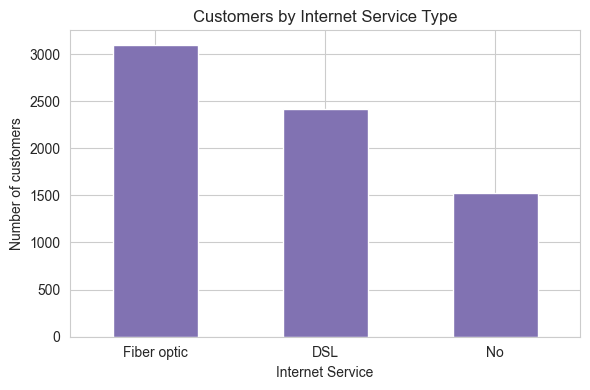

In [35]:
# Task 12 — categorical feature 2: InternetService distribution
plt.figure(figsize=(6,4))
df_clean_stage['InternetService'].value_counts().plot(kind='bar', color='#8172B2')
plt.title('Customers by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Fiber optic is the single largest group, DSL is close behind, and a meaningful chunk of customers have no internet service at all (phone-only). This means "internet quality" as a churn driver only applies to roughly two-thirds of the customer base.

**Answer 13 (outliers / skew and possible explanation):**
`tenure` and `MonthlyCharges` are both skewed/multi-modal rather than normally distributed, but there aren't extreme statistical outliers (both stay within sensible bounds — tenure 0–72 months, charges \$18–\$119). The shapes are explained by the business itself: tenure clusters at the start (new sign-ups) and end (loyal long-timers) of the observation window, and charges cluster around fixed service-bundle price points rather than varying continuously — so the multi-modality reflects real pricing tiers, not data-quality problems.

---

## Part 6 — Target Variable Analysis

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later.

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


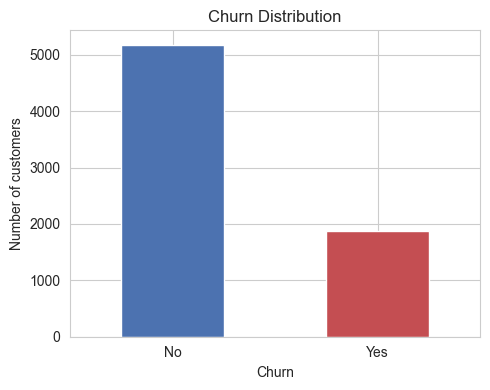

In [36]:
# Task 14 — churn counts and percentages
churn_counts = df_clean_stage['Churn'].value_counts()
churn_pct = df_clean_stage['Churn'].value_counts(normalize=True) * 100
print(churn_counts)
print()
print(churn_pct.round(2))

plt.figure(figsize=(5,4))
churn_counts.plot(kind='bar', color=['#4C72B0', '#C44E52'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Answer 14 (balanced or imbalanced?):**
5,174 customers did not churn (73.5%) and 1,869 did (26.5%). That's roughly a 3:1 ratio, so the target is **imbalanced** — not extremely so, but enough that it needs to be kept in mind for Lab 3.

**Answer 15 (why imbalance might matter later):**
A model can reach ~73% accuracy just by predicting "No churn" for everyone, so accuracy alone would look deceptively good while the model completely fails at its actual job of catching churners. It also means the training data gives the model far fewer churn examples to learn from, so it may need class weighting, resampling, or metrics like recall/F1/AUC instead of plain accuracy to be evaluated fairly.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

**Tasks**
16. Investigate at least 2 categorical features against Churn (Observation / Evidence / Possible Explanation).
17. Investigate at least 2 numerical features against Churn using the same format.

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


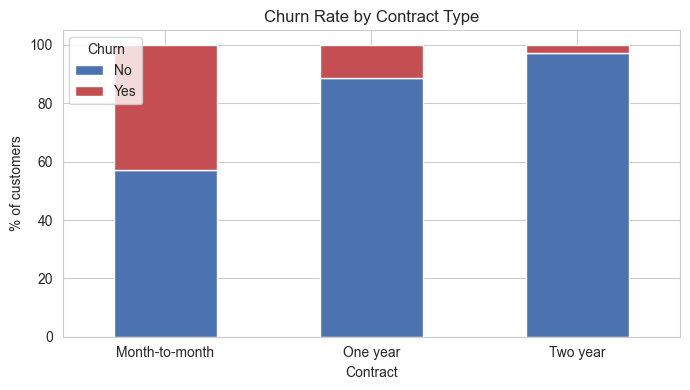

In [37]:
# Task 16 — categorical feature 1: Contract vs Churn
contract_churn = pd.crosstab(df_clean_stage['Contract'], df_clean_stage['Churn'], normalize='index') * 100
print(contract_churn.round(2))

contract_churn.plot(kind='bar', stacked=True, figsize=(7,4), color=['#4C72B0', '#C44E52'])
plt.title('Churn Rate by Contract Type')
plt.ylabel('% of customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Observation:** Churn rate drops sharply as contract length increases.
**Evidence:** Month-to-month churns at ~42.7%, One year at ~11.3%, Two year at only ~2.8%.
**Possible Explanation:** A month-to-month contract has no penalty for leaving, so unhappy (or price-sensitive) customers can act on that immediately, while longer contracts lock people in and naturally filter for customers who were already planning to stay.

Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


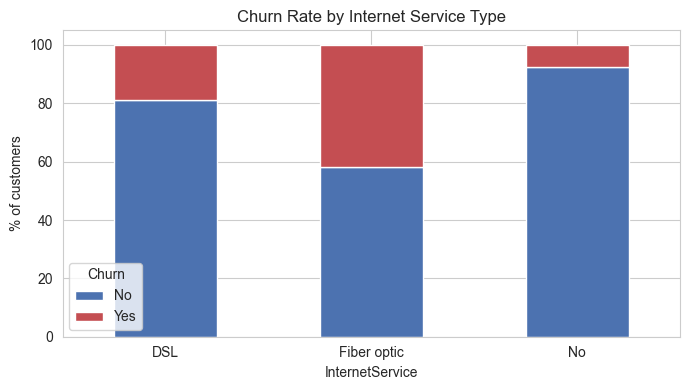

In [38]:
# Task 16 — categorical feature 2: InternetService vs Churn
internet_churn = pd.crosstab(df_clean_stage['InternetService'], df_clean_stage['Churn'], normalize='index') * 100
print(internet_churn.round(2))

internet_churn.plot(kind='bar', stacked=True, figsize=(7,4), color=['#4C72B0', '#C44E52'])
plt.title('Churn Rate by Internet Service Type')
plt.ylabel('% of customers')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

**Observation:** Fiber optic customers churn far more than DSL or no-internet customers.
**Evidence:** Fiber optic ~41.9% churn vs DSL ~19.0% and No internet ~7.4%.
**Possible Explanation:** Fiber is usually the most expensive tier (consistent with the MonthlyCharges pattern seen earlier), so it may be attracting customers with higher price sensitivity or unmet expectations about service quality/reliability, both of which push churn up.

        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5174.0  37.569965  24.113777  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


C:\Users\Talha\AppData\Local\Temp\ipykernel_15344\1303229094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df_clean_stage, palette=['#4C72B0', '#C44E52'])


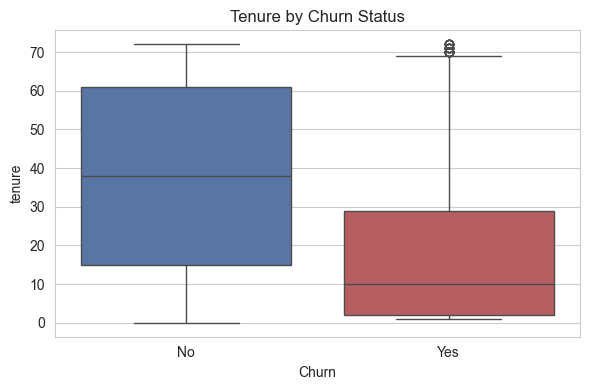

In [39]:
# Task 17 — numerical feature 1: tenure vs Churn
print(df_clean_stage.groupby('Churn')['tenure'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='tenure', data=df_clean_stage, palette=['#4C72B0', '#C44E52'])
plt.title('Tenure by Churn Status')
plt.tight_layout()
plt.show()

**Observation:** Customers who churn have been with the company for a much shorter time.
**Evidence:** Median tenure is 10 months for churners vs 38 months for non-churners (mean ~18 vs ~38 months).
**Possible Explanation:** This matches the contract finding — new customers haven't yet "locked in" via long contracts or built up loyalty/switching costs, so churn risk is concentrated early in the customer lifecycle.

        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


C:\Users\Talha\AppData\Local\Temp\ipykernel_15344\2623682389.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean_stage, palette=['#4C72B0', '#C44E52'])


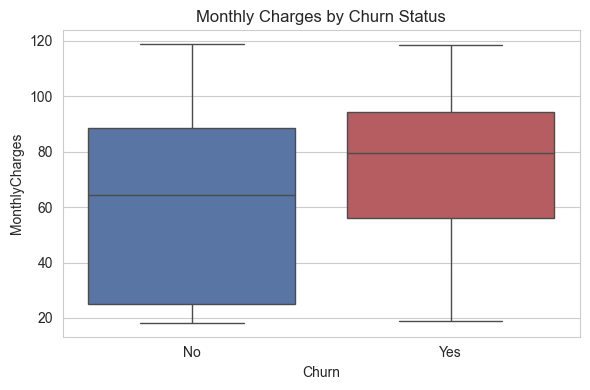

In [40]:
# Task 17 — numerical feature 2: MonthlyCharges vs Churn
print(df_clean_stage.groupby('Churn')['MonthlyCharges'].describe())

plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_clean_stage, palette=['#4C72B0', '#C44E52'])
plt.title('Monthly Charges by Churn Status')
plt.tight_layout()
plt.show()

**Observation:** Churners tend to pay more per month than customers who stay.
**Evidence:** Median MonthlyCharges is ~\$79.65 for churners vs ~\$64.43 for non-churners.
**Possible Explanation:** Higher bills are consistent with the fiber-optic finding above — customers on pricier, higher-tier services appear more likely to leave, possibly because they feel the price isn't justified or because they're more actively price-shopping competitors.

---

## Part 8 — Correlation & Feature Relationships

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model?

                tenure  MonthlyCharges  TotalCharges  SeniorCitizen
tenure           1.000           0.248         0.826          0.017
MonthlyCharges   0.248           1.000         0.651          0.220
TotalCharges     0.826           0.651         1.000          0.103
SeniorCitizen    0.017           0.220         0.103          1.000


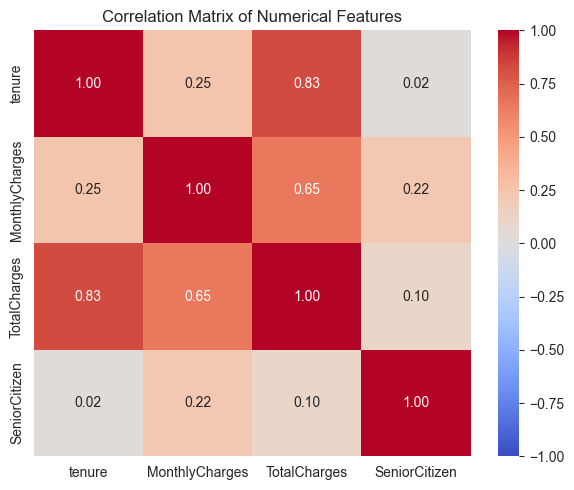

In [41]:
# Task 18 — correlation matrix and heatmap
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
corr_matrix = df_clean_stage[numeric_cols].corr()
print(corr_matrix.round(3))

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

**Answer 18 (most correlated pairs):**
`tenure` and `TotalCharges` are the most strongly correlated pair (**r ≈ 0.83**), followed by `MonthlyCharges` and `TotalCharges` (**r ≈ 0.65**). `MonthlyCharges` and `tenure` are only weakly correlated (**r ≈ 0.25**), and `SeniorCitizen` has little linear relationship with any of the billing/tenure fields.

**Answer 19 (correlation vs. causation; potential problems):**
No — correlation here is really just arithmetic, not causation: `TotalCharges` is roughly `tenure × MonthlyCharges` accumulated over time, so of course it tracks both closely. This is a redundancy problem for modeling: `TotalCharges` doesn't add much *new* information beyond `tenure` and `MonthlyCharges` combined, and including all three could inflate the importance of that shared signal or cause multicollinearity issues in linear models.

---

## Part 9 — Data Leakage Awareness

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
- `customerID` — not a leakage risk in the "future information" sense, but it's a pure identifier with no genuine predictive signal, so it must be excluded from modeling.
- `TotalCharges` — this is a borderline case rather than clear leakage: it's known at prediction time (it's the customer's running bill so far, not something that only exists after they've left), but because it's almost entirely explained by `tenure × MonthlyCharges` (Part 8), it risks acting as a proxy that quietly encodes tenure again rather than adding new signal.
- No column in this dataset (e.g. a cancellation date or reason-for-leaving field) directly reveals the outcome after the fact — the main leakage risk here is redundancy/proxy behavior rather than an outright "answer key" column.

**Answer 21 (what would go wrong):**
If a column that's only known *after* churn happens (or is essentially a restatement of the target) were included as a model input, the model would learn to rely on that shortcut instead of genuine behavioral patterns. It would then look artificially accurate during evaluation on historical data, but fail in production, because that information simply wouldn't be available yet for a customer whose churn status hasn't happened.

---

## Part 10 — ML-Readiness Checklist

**Task**
22. Complete the ML-readiness table for all columns in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | Unique per row, no predictive value |
| gender | Categorical | Feature | Keep, encode | Clean 2-category column; weak but harmless candidate feature |
| SeniorCitizen | Numerical (0/1 flag) | Feature | Keep as-is | Already numeric-encoded, no cleaning needed |
| Partner | Categorical | Feature | Keep, encode | Clean 2-category Yes/No column |
| Dependents | Categorical | Feature | Keep, encode | Clean 2-category Yes/No column |
| tenure | Numerical | Feature | Keep as-is | Strong candidate predictor (Part 7 finding) |
| PhoneService | Categorical | Feature | Keep, encode | Clean 2-category Yes/No column |
| MultipleLines | Categorical | Feature | Keep, encode | 3 categories incl. "No phone service" |
| InternetService | Categorical | Feature | Keep, encode | Strong candidate predictor (Part 7 finding) |
| OnlineSecurity | Categorical | Feature | Keep, encode | 3 categories incl. "No internet service" |
| OnlineBackup | Categorical | Feature | Keep, encode | 3 categories incl. "No internet service" |
| DeviceProtection | Categorical | Feature | Keep, encode | 3 categories incl. "No internet service" |
| TechSupport | Categorical | Feature | Keep, encode | 3 categories incl. "No internet service" |
| StreamingTV | Categorical | Feature | Keep, encode | 3 categories incl. "No internet service" |
| StreamingMovies | Categorical | Feature | Keep, encode | 3 categories incl. "No internet service" |
| Contract | Categorical | Feature | Keep, encode | Strongest candidate predictor (Part 7 finding) |
| PaperlessBilling | Categorical | Feature | Keep, encode | Clean 2-category Yes/No column |
| PaymentMethod | Categorical | Feature | Keep, encode | Meaningful churn differences seen in EDA |
| MonthlyCharges | Numerical | Feature | Keep as-is | Cleaned already; strong candidate predictor |
| TotalCharges | Numerical (was text) | Feature | Keep, cleaned | Converted to numeric, 11 blanks filled with 0; watch for redundancy with tenure × MonthlyCharges (Part 8/9) |
| Churn | Categorical | **Target** | Keep | This is the label to predict in Lab 3 |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified.
24. Print `df.info()` for `clean_df` as final proof that every issue identified earlier has been resolved.

In [42]:
# Task 23 — assemble clean_df from the cleaning decisions
clean_df = df.copy()

# Fix TotalCharges: convert to numeric, fill the 11 genuinely-zero (tenure==0) rows with 0
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df['TotalCharges'] = clean_df['TotalCharges'].fillna(0)

# No full-row or customerID duplicates were found (Part 3), so drop_duplicates()
# is a defensive no-op here rather than something that changes the data
clean_df = clean_df.drop_duplicates()

# customerID kept for traceability at this stage; flagged as "drop before
# modeling" in the ML-readiness table (Part 10) -- Lab 3 will remove it
# right before training, not here.

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)
print("Saved clean_churn.csv with shape:", clean_df.shape)

Saved clean_churn.csv with shape: (7043, 21)


In [43]:
# Task 24 — final proof: info(), isnull().sum(), duplicated().sum() on clean_df
clean_df.info()
print()
print("Missing values remaining:")
print(clean_df.isnull().sum().sum())
print()
print("Duplicate rows remaining:", clean_df.duplicated().sum())
print("Duplicate customerIDs remaining:", clean_df['customerID'].duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


---

## Part 12 — Key Findings & Final Reflection

**Task 25 — Five Important Findings**

**Finding 1**
- Observation: Contract type is the single strongest churn signal found.
- Evidence: Churn rate is ~42.7% for Month-to-month vs ~11.3% for One year and ~2.8% for Two year.
- Interpretation: Contract commitment (or lack of it) is doing a lot of the explanatory work — this should be one of the top features going into Lab 3's model.

**Finding 2**
- Observation: New customers are far more likely to churn than long-tenured ones.
- Evidence: Median tenure is 10 months for churners vs 38 months for non-churners.
- Interpretation: There's likely an "early risk window" in the customer lifecycle where retention effort would have the most impact.

**Finding 3**
- Observation: Fiber optic internet customers churn at a much higher rate than DSL or no-internet customers.
- Evidence: ~41.9% churn for Fiber optic vs ~19.0% for DSL and ~7.4% for No internet service.
- Interpretation: The priciest, most feature-rich service tier is paradoxically the least "sticky" — possibly a price or reliability perception issue worth flagging to the business, not just the model.

**Finding 4**
- Observation: `TotalCharges` was hiding a data-quality issue: it was stored as text with 11 blank entries.
- Evidence: `pd.to_numeric(..., errors='coerce')` revealed exactly 11 rows, all with `tenure == 0`.
- Interpretation: A missing-value check that only trusts `isnull().sum()` on a badly-typed column would have missed this entirely — a reminder to check both dtype *and* nulls, not just one.

**Finding 5**
- Observation: The target class is imbalanced (~73.5% No vs ~26.5% Yes).
- Evidence: 5,174 vs 1,869 customers respectively.
- Interpretation: Lab 3's model choice, training strategy, and evaluation metric all need to account for this rather than relying on plain accuracy.

**Final Reflection Questions**

- **What was the most important data-quality issue you found?**
  The `TotalCharges` column being stored as text with 11 disguised blank values — it wouldn't show up in a naive `isnull().sum()` check, which is a good reminder to always check dtypes first.

- **What was the most interesting pattern you discovered?**
  How consistently three separate signals (contract length, tenure, and internet service tier) all point to the same underlying story: customers with less "lock-in" and higher perceived cost churn more.

- **Which feature seems most useful for predicting churn?**
  `Contract`, based on how sharply churn rate changes across its three categories in the bivariate analysis.

- **Which feature should probably not be used, and why?**
  `customerID` — it's a unique identifier with no relationship to customer behavior and can't generalize to new customers.

- **What preprocessing will be required before ML modeling (conceptually — do not implement it)?**
  Categorical columns will need encoding (e.g. one-hot encoding) since most features here are Yes/No or multi-category text; numerical features like `MonthlyCharges` and `TotalCharges` may benefit from scaling depending on the model; and the class imbalance will need to be addressed via class weighting, resampling, or an appropriate evaluation metric.

- **What would you do next if you had another 3 hours?**
  Dig deeper into interaction effects — for example, whether the "Fiber optic + Month-to-month" combination is disproportionately high-churn compared to either factor alone — and start sketching candidate engineered features (like a tenure-bucket variable) for Lab 3.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.53   2.47
Two year       DSL              98.09   1.91
               Fiber optic      92.77   7.23
               No               99.22   0.78


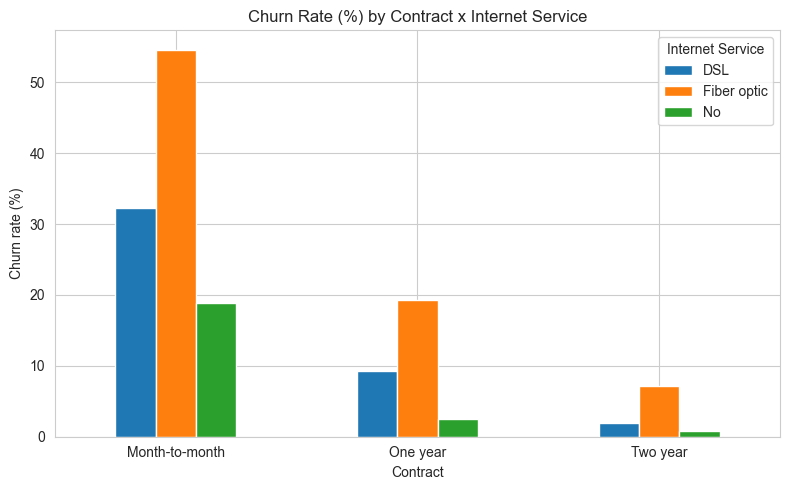

In [44]:
# Bonus — churn rate across a combination of Contract and InternetService
combo = pd.crosstab(
    [clean_df['Contract'], clean_df['InternetService']],
    clean_df['Churn'],
    normalize='index'
) * 100
print(combo.round(2))

combo['Yes'].unstack().plot(kind='bar', figsize=(8,5))
plt.title('Churn Rate (%) by Contract x Internet Service')
plt.ylabel('Churn rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Internet Service')
plt.tight_layout()
plt.show()

**Bonus finding:** Combining Contract and InternetService shows the two risk factors stack: Month-to-month + Fiber optic customers churn at the highest rate of any segment, noticeably higher than either factor alone would suggest — a strong candidate for a Lab 3 interaction/engineered feature.

**Feature-engineering opportunity:** A `tenure_bucket` (e.g. 0–6, 7–12, 13–24, 25+ months) or a combined `Contract_InternetService` interaction feature could capture the non-linear "early risk window" and stacking-risk patterns seen above more directly than the raw columns alone.

**Possible source of bias:** The dataset is a snapshot from one telecom provider at one point in time — customer behavior, pricing, and competition can shift, so patterns learned here (e.g. exactly *how much* fiber customers churn) may not transfer to a different region, time period, or company without re-validation.

---

## Submission Checklist

Before submitting, confirm you have:

- [x] Completed all 26 tasks above, with written interpretation for every chart and decision
- [x] A working `clean_df`, saved as `clean_churn.csv`
- [x] A completed ML-readiness table (Part 10) covering every column
- [x] Five Key Findings written (Part 12)
- [x] Answered all six Final Reflection questions
- [ ] Committed and pushed the notebook + `clean_churn.csv` to a GitHub repository (link to be added above before submission)